# **Example of non-commutativity of rotation gates**
---
<img src="Imperial_logo.png" align = "left" width=200>
<br><br>
 
- Copyright (c) Jack Jacquier, 2022. All rights reserved

- Author: Jack Jacquier <a.jacquier@imperial.ac.uk>

- Platform: Tested on Windows 10 with Python 3.9

In [1]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_state_qsphere, plot_bloch_vector
from qiskit_aer import Aer
import matplotlib.pylab as plt
from qiskit.visualization import plot_histogram
import numpy as np

$$\newcommand{\ket}[1]{\left|{#1}\right\rangle}$$
$$\newcommand{\bra}[1]{\left\langle{#1}\right|}$$
$$\newcommand{\braket}[2]{\left\langle{#1}|\right\rangle}$$

We consider the two quantum gates $\mathtt{H}$ (Hadamard) and $\mathtt{R}_{\mathtt{Y}}\left(\frac{\pi}{2}\right)$,
where we recall that
$$
\mathtt{R}_{\mathtt{Y}}(\theta) = 
\begin{pmatrix}
\cos(\frac{\theta}{2}) & -\sin(\frac{\theta}{2})\\
\sin(\frac{\theta}{2}) & \cos(\frac{\theta}{2}).
 \end{pmatrix},
$$
so that 
$$
\mathtt{R}_{\mathtt{Y}}\left(\frac{\pi}{2}\right) = 
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & -1\\
1 & 1.
 \end{pmatrix},
$$
The first circuit is given by
$$
\ket{\Phi} := \mathtt{H}\cdot\mathtt{R}_{\mathtt{Y}}\left(\frac{\pi}{2}\right)\ket{0}
$$
while the second swaps the two gates:
$$
\ket{\Psi} := \mathtt{R}_{\mathtt{Y}}\left(\frac{\pi}{2}\right)\cdot\mathtt{H}\ket{0}
$$
Explicit computations give, since $\cos(\frac{\pi}{4}) = \frac{1}{\sqrt{2}} = \sin(\frac{\pi}{4})$,
$$
\ket{\Phi} = \frac{1}{\sqrt{2}}\mathtt{H}\Big(\ket{0} - \ket{1}\Big)
 = \frac{1}{2}\Big(\ket{0} + \ket{1} - (\ket{0} - \ket{1})\Big)
 = \ket{1},
$$
while
$$
\ket{\Psi} = \mathtt{R}_{\mathtt{Y}}\left(\frac{\pi}{2}\right) \frac{\ket{0}+\ket{1}}{\sqrt{2}} \\
= \frac{1}{2}(\ket{0} - \ket{1} + \ket{0} + \ket{1})
 = \ket{0}
$$

So the two gates clearly do not commute. We now check this numerically.

In [3]:
theta = np.pi / 2.

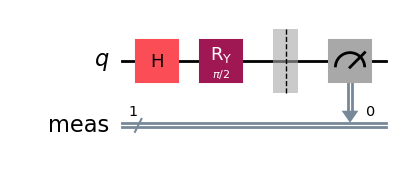

In [4]:
qc = QuantumCircuit(1)
qc.h(0)
qc.ry(theta,0)
qc.measure_all()
qc.draw('mpl')

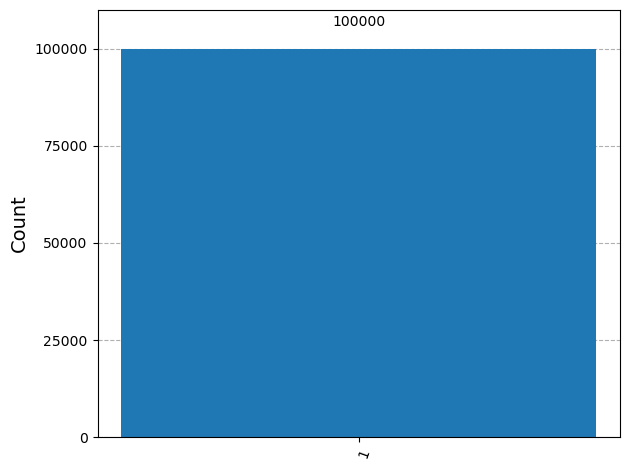

In [5]:
backend = Aer.get_backend('qasm_simulator')
shots = 100000
results = backend.run(qc, backend=backend, shots=shots).result()
plot_histogram(results.get_counts())

Consider now the same quantum circuit, but with the two quantum gates swapped:

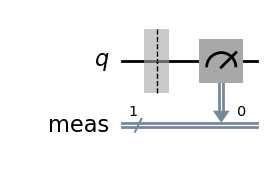

In [6]:
qc2 = QuantumCircuit(1)
qc.ry(theta,0)
qc.h(0)
qc2.measure_all()
qc2.draw('mpl')

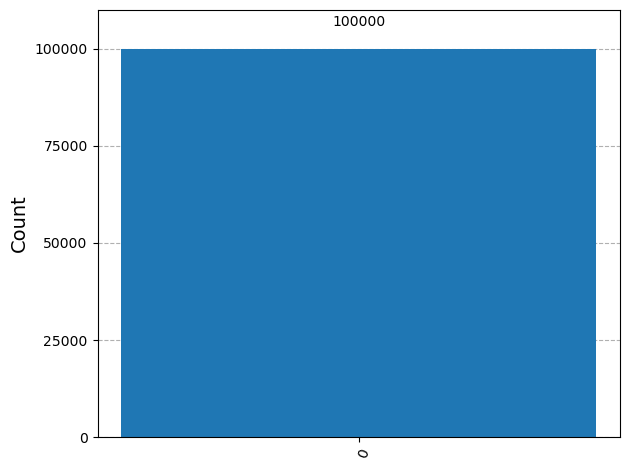

In [7]:
backend = Aer.get_backend('qasm_simulator')
shots = 100000
results = backend.run(qc2, backend=backend, shots=shots).result()
plot_histogram(results.get_counts())